# 02 · Análise exploratória e hipóteses

O enunciado pede que a EDA apoie diretamente as decisões de modelagem. Então este notebook tem um formato de pergunta e resposta: cada bloco levanta uma hipótese sobre o que explica a alfabetização, testa com o dado real e registra o que isso muda no desenho do pipeline. No fim há uma tabela consolidando as decisões.

Duas bases entram aqui:

- **ABT de município** (uma linha por município e ano-alvo), com o histórico do indicador, o Censo Escolar, o rendimento, o IDEB, o território, a renda e o INSE;
- **ABT de aluno** (uma linha por aluno avaliado em 2024 e 2025), com rede, escola e o contexto municipal do mesmo ano.

A EDA usa as duas linhas de 2024 e 2025 da ABT de município (as que têm alvo). Para o grão de aluno, os gráficos usam uma amostra estratificada de 400 mil alunos, mas as estatísticas são calculadas na base inteira.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data.abt import carregar_abt_aluno
from src.visualization.estilo import aplicar_estilo, salvar, fmt_pct, AZUL, LARANJA, CINZA, VERDE, VERMELHO, CORES_REGIAO
from src.visualization.rotulos import rotulo, rotular

aplicar_estilo()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
SEED = 42

abt = pd.read_parquet("data/processed/abt_municipio.parquet")
mun = abt[abt["ano_alvo"].isin([2024, 2025]) & abt["atingiu_meta_t"].notna()].copy()
mun["atingiu"] = mun["atingiu_meta_t"].astype(int)
mun["ano_alvo"] = mun["ano_alvo"].astype(int)
print(mun.shape, mun.groupby("ano_alvo").size().to_dict())

(10864, 61) {2024: 5425, 2025: 5439}


## 1. O alvo no grão de município

Duas leituras do mesmo resultado: o percentual de alunos alfabetizados (`indicador_t`) e se o município atingiu a meta do ano (`atingiu_meta_t`). A segunda é a que a política pública cobra, então é o alvo do modelo de risco. Mas a primeira mostra o quanto o alvo binário esconde.

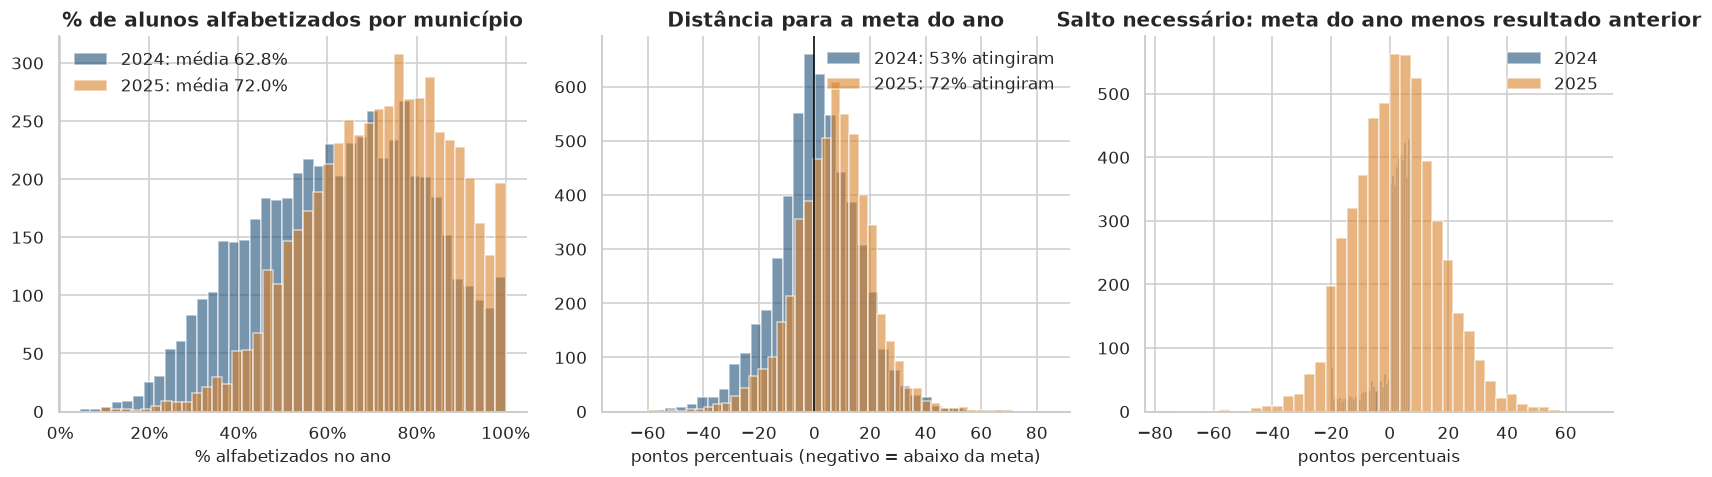

,mean,50%,min,max
ano_alvo,,,,
2024,1.7,3.2,-20.0,7.5
2025,2.3,2.3,-76.3,68.9


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ano, cor in zip([2024, 2025], [AZUL, LARANJA]):
    d = mun[mun["ano_alvo"] == ano]
    axes[0].hist(d["indicador_t"], bins=40, alpha=0.6, color=cor, label=f"{ano}: média {d['indicador_t'].mean():.1f}%")
    axes[1].hist(d["gap_meta_t"], bins=40, alpha=0.6, color=cor, label=f"{ano}: {100 * d['atingiu'].mean():.0f}% atingiram")
axes[0].set_title("% de alunos alfabetizados por município")
axes[0].set_xlabel("% alfabetizados no ano")
axes[0].legend()
fmt_pct(axes[0])
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Distância para a meta do ano")
axes[1].set_xlabel("pontos percentuais (negativo = abaixo da meta)")
axes[1].legend()

salto = mun.groupby("ano_alvo")["salto_necessario"].describe()[["mean", "50%", "min", "max"]].round(1)
axes[2].hist(mun.loc[mun["ano_alvo"] == 2024, "salto_necessario"].dropna(), bins=40, color=AZUL, alpha=0.6, label="2024")
axes[2].hist(mun.loc[mun["ano_alvo"] == 2025, "salto_necessario"].dropna(), bins=40, color=LARANJA, alpha=0.6, label="2025")
axes[2].set_title("Salto necessário: meta do ano menos resultado anterior")
axes[2].set_xlabel("pontos percentuais")
axes[2].legend()
salvar(fig, "02_alvo_municipio")
plt.show()
salto

O alvo binário é razoavelmente equilibrado em 2024 (53% atingiram) e desequilibra em 2025 (72%), porque o país avançou mais do que as metas pediam. Isso tem duas consequências. A primeira é que a taxa base muda de um ano para o outro: um modelo treinado em 2024 vai subestimar a chance de atingir a meta em 2025, e é exatamente o tipo de deriva que o backtest temporal precisa mostrar. A segunda é que a distância para a meta se concentra perto de zero: muitos municípios decidem o resultado por poucos pontos, e um modelo de classificação vai errar mais nessa faixa. Por isso o modelo de risco vai entregar probabilidade, não só a classe, e a lista de prioridade usa a probabilidade ordenada.

## 2. Território: o quanto a UF explica

**H1. A UF explica uma parcela grande da variação do indicador entre municípios.** Se for verdade, o modelo precisa de UF como variável e a validação precisa separar municípios (não UFs) entre treino e validação, senão o modelo é avaliado num cenário que nunca vai acontecer (uma UF inteira nova).

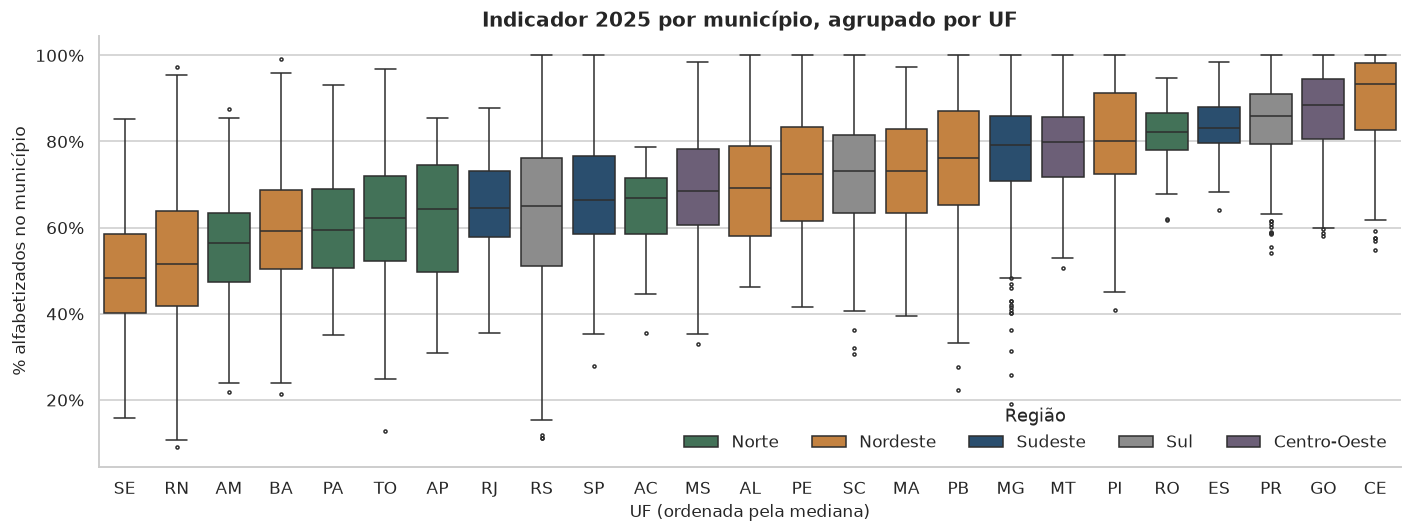

Kruskal-Wallis entre UFs: H = 1923, p = 0.0e+00; variância explicada pela UF (eta²) = 0.35
variância explicada pela região (eta²) = 0.06


In [3]:
d = mun[mun["ano_alvo"] == 2025]
ordem = d.groupby("sigla_uf")["indicador_t"].median().sort_values().index
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=d, x="sigla_uf", y="indicador_t", order=ordem, hue="nome_regiao", palette=CORES_REGIAO, dodge=False, ax=ax, fliersize=2)
ax.set_title("Indicador 2025 por município, agrupado por UF")
ax.set_xlabel("UF (ordenada pela mediana)")
ax.set_ylabel("% alfabetizados no município")
ax.legend(title="Região", loc="lower right", ncol=5)
fmt_pct(ax, "y")
salvar(fig, "02_indicador_por_uf")
plt.show()

grupos = [g["indicador_t"].values for _, g in d.groupby("sigla_uf")]
h, p = stats.kruskal(*grupos)
# eta quadrado como medida de tamanho de efeito (variancia explicada pelos grupos)
ss_entre = sum(len(g) * (g.mean() - d["indicador_t"].mean()) ** 2 for g in grupos)
ss_total = ((d["indicador_t"] - d["indicador_t"].mean()) ** 2).sum()
print(f"Kruskal-Wallis entre UFs: H = {h:.0f}, p = {p:.1e}; variância explicada pela UF (eta²) = {ss_entre / ss_total:.2f}")
grupos_reg = [g["indicador_t"].values for _, g in d.groupby("nome_regiao")]
ss_reg = sum(len(g) * (g.mean() - d["indicador_t"].mean()) ** 2 for g in grupos_reg)
print(f"variância explicada pela região (eta²) = {ss_reg / ss_total:.2f}")

A UF explica cerca de um terço da variação entre municípios (eta² de 0,35). A região explica quase nada (0,06): o que importa não é Nordeste versus Sul, e sim o estado. Ceará e Bahia são vizinhos e estão em extremos opostos. Isso tem duas leituras. Uma é de política: a gestão estadual (regime de colaboração, programas de alfabetização, formação) faz diferença enorme. A outra é de medição: cada UF aplica a própria avaliação, pareada à escala Saeb, e parte da diferença pode ser de instrumento. O modelo não consegue separar as duas coisas, e isso vai para as limitações.

**Decisão:** UF entra como variável categórica (one-hot, 27 categorias é pouco); a validação usa `StratifiedGroupKFold` com o município como grupo; e a região fica de fora por ser redundante com a UF.

## 3. Contexto socioeconômico e territorial

**H2.** O nível socioeconômico dos alunos (INSE) se associa positivamente ao indicador.
**H3.** Municípios com mais alunos em escolas rurais têm indicador menor.
**H4.** PIB per capita se associa ao indicador, mas menos do que o INSE (renda do território é um proxy pior do que a renda das famílias dos alunos).

In [4]:
def spearman(df, x, y="indicador_t"):
    d = df[[x, y]].dropna()
    r, p = stats.spearmanr(d[x], d[y])
    return r, p, len(d)

variaveis_contexto = ["inse_medio", "inse_pct_nivel_baixo", "pct_alunos_rural", "pib_per_capita", "log_populacao", "densidade_hab_km2", "pct_vab_agro", "pct_vab_adm_publica"]
linhas = []
for v in variaveis_contexto:
    r, p, n = spearman(d, v)
    linhas.append({"variavel": rotulo(v), "spearman": round(r, 3), "p_valor": f"{p:.1e}", "n": n})
pd.DataFrame(linhas).sort_values("spearman", key=abs, ascending=False)

,variavel,spearman,p_valor,n
4,População (escala log),-0.278,5.5e-97,5439
6,Peso da agropecuária na economia (%),0.204,2.2e-52,5439
2,Alunos em escolas rurais (%),-0.156,9.3e-31,5428
5,Densidade demográfica (hab/km2),-0.123,8.0e-20,5439
0,Nível socioeconômico médio dos alunos (INSE),0.089,5.4e-11,5428
1,Alunos nos níveis socioeconômicos baixos (%),-0.089,6.0e-11,5428
7,Peso da administração pública na economia (%),-0.039,4.2e-03,5439
3,PIB per capita (R$),0.035,9.2e-03,5439


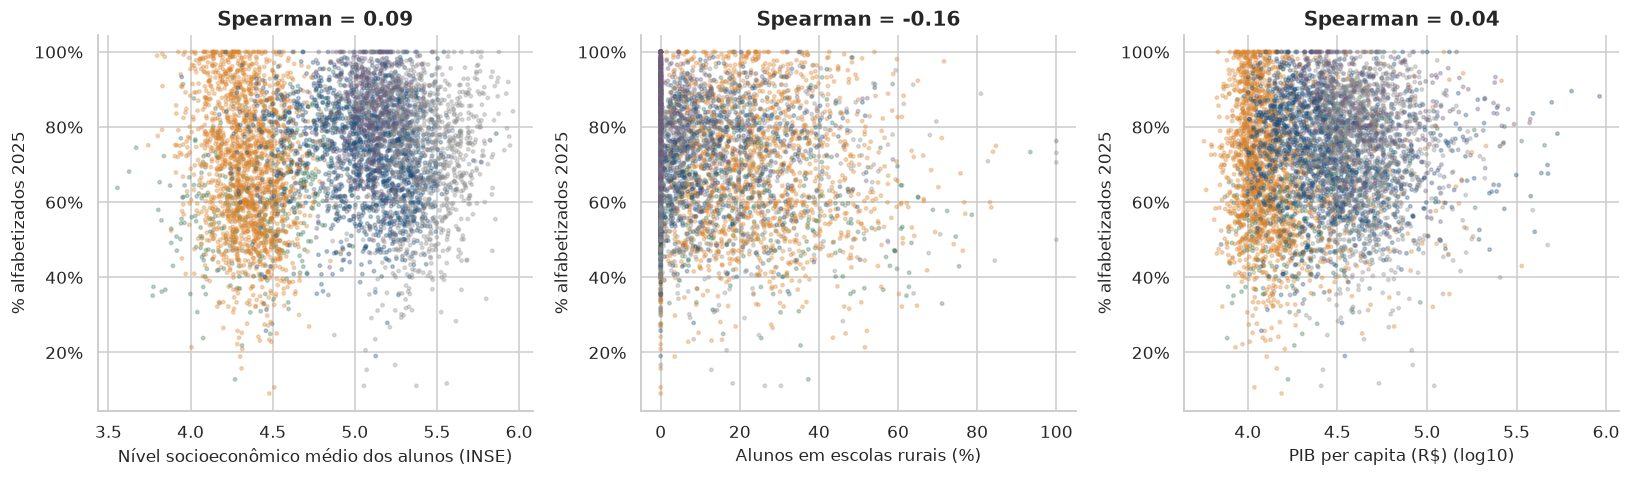

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, v in zip(axes, ["inse_medio", "pct_alunos_rural", "pib_per_capita"]):
    dd = d[[v, "indicador_t", "nome_regiao"]].dropna()
    xs = np.log10(dd[v]) if v == "pib_per_capita" else dd[v]
    ax.scatter(xs, dd["indicador_t"], s=5, alpha=0.3, c=dd["nome_regiao"].map(CORES_REGIAO))
    ax.set_xlabel(rotulo(v) + (" (log10)" if v == "pib_per_capita" else ""))
    ax.set_ylabel("% alfabetizados 2025")
    r, p, n = spearman(d, v)
    ax.set_title(f"Spearman = {r:.2f}")
    fmt_pct(ax, "y")
salvar(fig, "02_contexto_socioeconomico")
plt.show()

O resultado surpreende. H2 e H4 se confirmam no sinal, mas com força bem menor do que eu esperava: INSE tem correlação positiva e fraca (0,09) e PIB per capita quase nula. A variável de contexto mais associada ao indicador é o **porte**: municípios menores (e mais agrícolas) têm indicador maior, com correlação negativa de 0,28 com a população. H3 vai no sentido oposto do porte: mais alunos em escola rural, indicador menor, mas o efeito é modesto (0,16).

A leitura que faz sentido é que, no 2º ano, o que separa os municípios não é a renda das famílias, e sim a capacidade da rede de alfabetizar na idade certa, e redes pequenas com política estadual forte (o caso do Ceará e do Piauí) conseguem isso mesmo com INSE baixo. O gráfico do INSE mostra exatamente isso: municípios nordestinos com INSE baixo espalhados do topo à base.

**Decisão:** INSE, ruralidade, porte (log da população), estrutura produtiva e PIB per capita entram como variáveis numéricas. PIB per capita, população, área e densidade recebem transformação log dentro do pipeline por serem muito assimétricas (bloco 7). A expectativa, a confirmar no SHAP, é que o contexto socioeconômico pese pouco perto do histórico e do fluxo escolar.

## 4. Condições de ensino

**H5.** Formação docente adequada nos anos iniciais se associa a indicador maior.
**H6.** Turmas maiores se associam a indicador menor.
**H7.** Distorção idade-série nos anos iniciais se associa a indicador menor (é sintoma de fluxo ruim antes da prova).
**H8.** Aprovação no 2º ano do ano anterior se associa a indicador maior.

In [6]:
variaveis_ensino = ["afd_ai_grupo1_pct", "afd_ai_grupo5_pct", "docentes_superior_ai_pct", "alunos_por_turma_ai", "alunos_por_turma_2ano", "distorcao_ai_pct", "distorcao_2ano_pct", "aprovacao_2ano_pct", "reprovacao_ai_pct", "abandono_ai_pct", "afd_inf_grupo1_pct", "alunos_por_turma_pre"]
linhas = []
for v in variaveis_ensino:
    r, p, n = spearman(d, v)
    linhas.append({"variavel": rotulo(v), "spearman": round(r, 3), "p_valor": f"{p:.1e}", "n": n})
pd.DataFrame(linhas).sort_values("spearman", key=abs, ascending=False)

,variavel,spearman,p_valor,n
9,"Taxa de abandono, anos iniciais (%)",-0.386,9.0e-193,5439
8,"Taxa de reprovação, anos iniciais (%)",-0.357,8.5e-163,5439
5,"Distorção idade-série, anos iniciais (%)",-0.347,6.7e-154,5439
1,"Docentes sem licenciatura, anos iniciais (%)",-0.197,1.8e-48,5437
2,"Docentes com curso superior, anos iniciais (%)",0.191,7.8e-46,5439
6,Distorção idade-série no 2o ano (%),-0.178,7.2e-40,5438
7,Taxa de aprovação no 2o ano (%),0.158,6.7e-32,5439
3,"Alunos por turma, anos iniciais",-0.117,5.9e-18,5439
4,Alunos por turma no 2o ano,-0.097,8.6e-13,5438
0,"Docentes com formação adequada, anos iniciais (%)",0.090,2.8e-11,5437


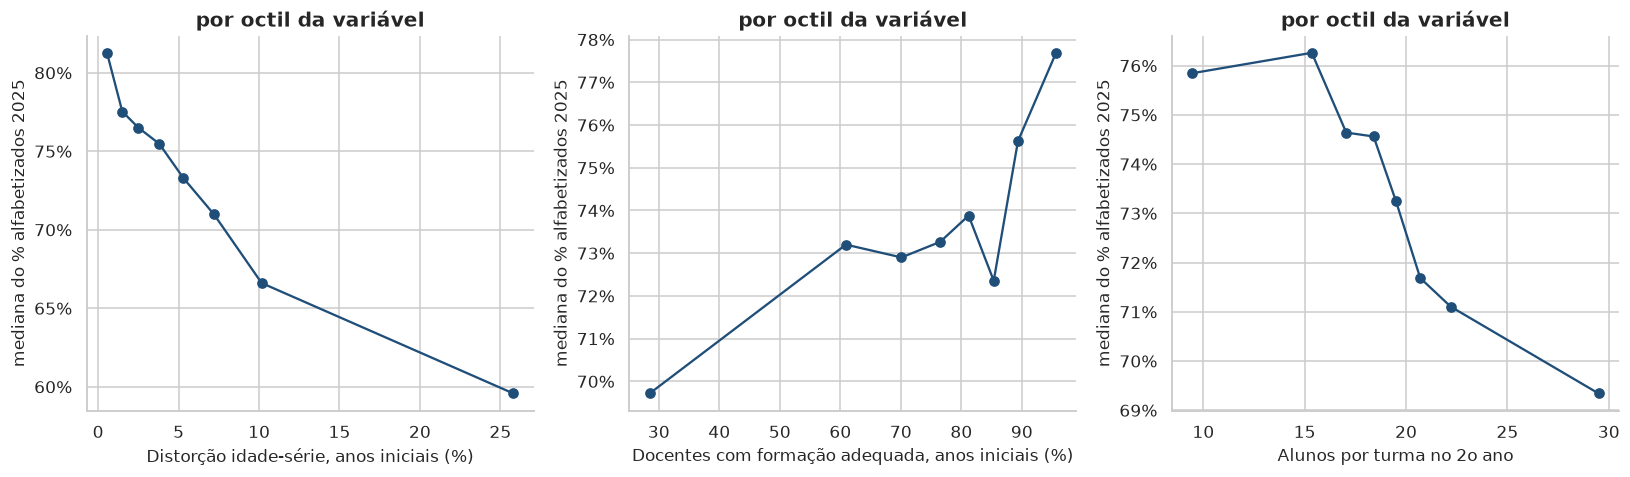

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, v in zip(axes, ["distorcao_ai_pct", "afd_ai_grupo1_pct", "alunos_por_turma_2ano"]):
    dd = d[[v, "indicador_t"]].dropna()
    dd["faixa"] = pd.qcut(dd[v], 8, duplicates="drop")
    resumo = dd.groupby("faixa", observed=True)["indicador_t"].agg(["median", "count"]).reset_index()
    resumo["x"] = [iv.mid for iv in resumo["faixa"]]
    ax.plot(resumo["x"], resumo["median"], marker="o", color=AZUL)
    ax.set_xlabel(rotulo(v))
    ax.set_ylabel("mediana do % alfabetizados 2025")
    ax.set_title("por octil da variável")
    fmt_pct(ax, "y")
salvar(fig, "02_condicoes_de_ensino")
plt.show()

O bloco de fluxo escolar é o mais forte de todos os contextos: abandono (−0,39), reprovação (−0,36) e distorção idade-série (−0,35) nos anos iniciais têm correlação negativa clara e aproximadamente monotônica. H7 se confirma. H5 se confirma com efeito pequeno para a formação adequada (0,09) e um pouco maior para docentes com curso superior (0,19). H6 se confirma no sinal, com efeito pequeno (−0,12). H8 (aprovação no 2º ano) tem correlação positiva de 0,16.

Vale a ressalva de sempre: isso é associação. Distorção idade-série é sintoma de que a rede já vinha reprovando e retendo antes do 2º ano; é um excelente sinal de alerta, não necessariamente a causa.

**Decisão:** todas entram como numéricas. Como várias relações não são lineares (a mediana por octil satura nas pontas), a família de modelos precisa incluir árvores (Random Forest e Gradient Boosting); a regressão logística fica como baseline interpretável.

## 5. O passado como preditor

**H9.** O IDEB dos anos iniciais (uma medida de 5º ano, dois anos antes) prevê o indicador de 2º ano.
**H10.** O resultado do ano anterior é o preditor mais forte de todos.
**H11.** Quanto maior o salto necessário para a meta, menor a chance de atingi-la.

Se H10 for muito forte, existe um risco: o modelo pode virar um repetidor do ano anterior e a parte de contexto não acrescentar nada. Isso precisa ser medido na modelagem com uma ablação (modelo com e sem o histórico).

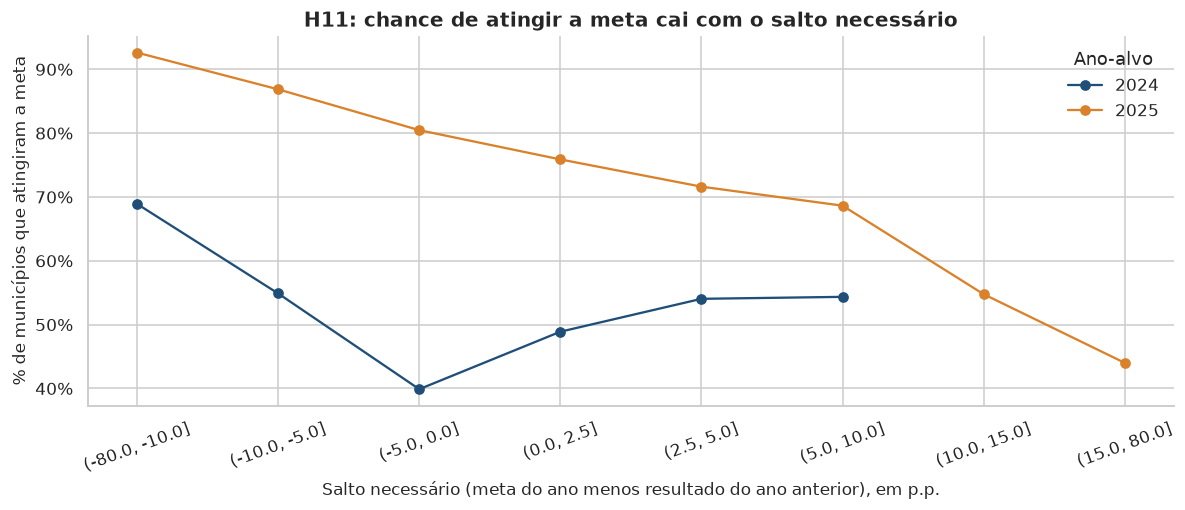

,variavel,spearman_com_indicador,p_valor
0,% alfabetizados no ano anterior,0.690,0.0e+00
1,Nível de alfabetização no ano anterior (0 a 5),0.678,0.0e+00
8,Meta do ano (%),0.571,0.0e+00
3,IDEB anos iniciais (última edição),0.492,0.0e+00
4,Nota de português no Saeb 5o ano (última edição),0.457,6.3e-273
7,Salto necessário para a meta (p.p.),-0.455,3.7e-274
2,Participação na prova no ano anterior (%),0.321,3.7e-128
6,Variação do IDEB entre edições,0.282,4.3e-90
5,Tendência do IDEB (pontos por edição),0.081,3.2e-09


In [8]:
linhas = []
for v in ["indicador_t1", "nivel_t1", "participacao_t1", "ideb_ultimo", "ideb_nota_lp_ultimo", "ideb_tendencia", "ideb_variacao", "salto_necessario", "meta_t"]:
    r, p, n = spearman(d, v)
    linhas.append({"variavel": rotulo(v), "spearman_com_indicador": round(r, 3), "p_valor": f"{p:.1e}"})
tabela = pd.DataFrame(linhas).sort_values("spearman_com_indicador", key=abs, ascending=False)

# H11 com o alvo binario: taxa de atingimento por faixa de salto necessario
dd = mun[["salto_necessario", "atingiu", "ano_alvo"]].dropna()
dd["faixa"] = pd.cut(dd["salto_necessario"], [-80, -10, -5, 0, 2.5, 5, 10, 15, 80])
taxa = dd.groupby(["faixa", "ano_alvo"], observed=True)["atingiu"].agg(["mean", "size"]).reset_index()
taxa = taxa[taxa["size"] >= 30]  # faixas com poucos municipios so acrescentam ruido
fig, ax = plt.subplots(figsize=(11, 4.8))
faixas = list(taxa["faixa"].cat.categories)
for ano, cor in zip([2024, 2025], [AZUL, LARANJA]):
    t = taxa[taxa["ano_alvo"] == ano]
    ax.plot([faixas.index(f) for f in t["faixa"]], 100 * t["mean"], marker="o", color=cor, label=str(ano))
ax.set_xticks(range(len(faixas)))
ax.set_xticklabels([str(iv) for iv in faixas], rotation=20)
ax.set_xlabel("Salto necessário (meta do ano menos resultado do ano anterior), em p.p.")
ax.set_ylabel("% de municípios que atingiram a meta")
ax.set_title("H11: chance de atingir a meta cai com o salto necessário")
ax.legend(title="Ano-alvo")
fmt_pct(ax, "y")
salvar(fig, "02_salto_necessario")
plt.show()
tabela

H10 se confirma com folga: o resultado do ano anterior é o preditor mais forte (0,69). H9 também: o IDEB dos anos iniciais, que mede outra série e outra prova, carrega muita informação sobre a rede (0,49). H11 é o achado mais útil para o gestor, e o gráfico mostra duas coisas. Em 2025 a chance de atingir a meta cai de forma quase linear com o salto necessário: quem precisava subir mais de 15 pontos tinha menos da metade da chance de quem já estava acima da meta. Em 2024 as metas foram calculadas a partir do resultado de 2023 e ficaram muito próximas dele (o salto raramente passa de 7 pontos), então a curva é curta e ruidosa, e aparece um efeito de regressão à média: municípios que em 2023 estavam bem acima da trajetória da meta caíram em 2024 com frequência.

**Decisão:** `indicador_t1`, `salto_necessario` e o bloco do IDEB entram no modelo. A ablação com e sem o histórico é obrigatória na modelagem. A deriva entre 2024 e 2025 (a curva laranja acima da azul em todas as faixas) confirma que o teste tem de ser temporal e que a probabilidade do modelo precisa ser lida com a taxa base do ano em mente.

## 6. Correlação entre as variáveis

Para a regressão logística e para a interpretabilidade importa saber quais variáveis andam juntas. Árvores lidam bem com colinearidade, mas o SHAP distribui o crédito entre variáveis correlacionadas, e vale conhecer os pares antes de ler os resultados.

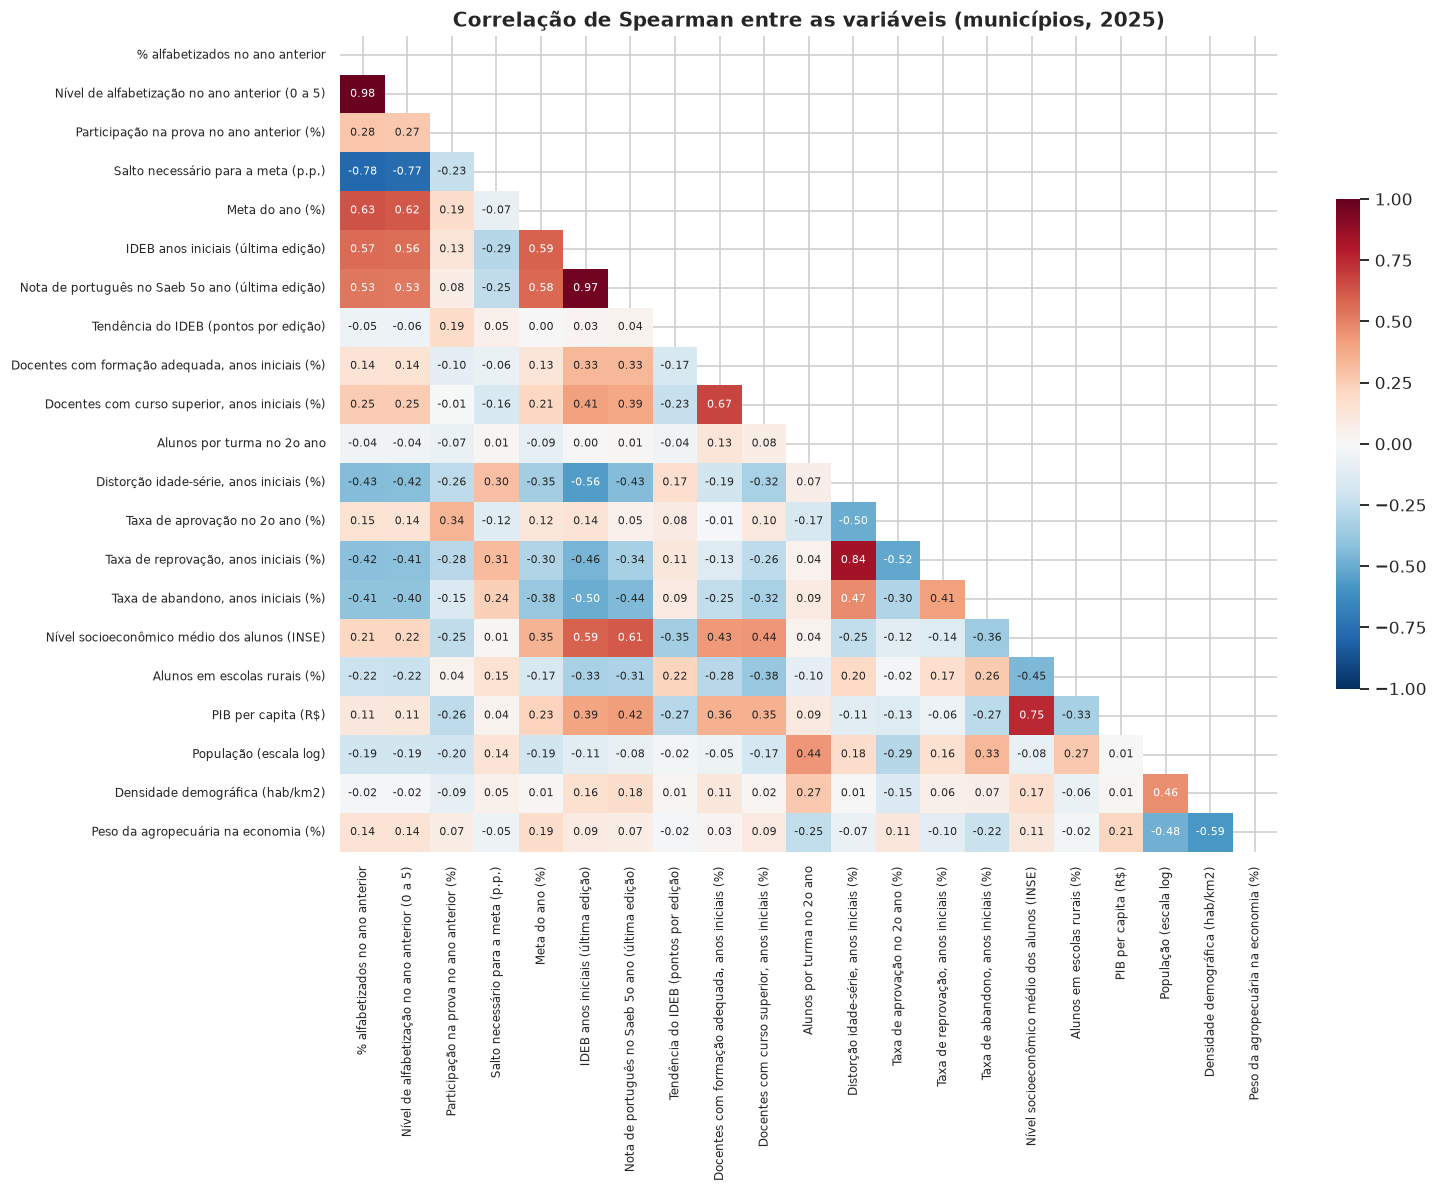

spearman
Nível de alfabetização no ano anterior (0 a 5)   % alfabetizados no ano anterior                        0.98
Nota de português no Saeb 5o ano (última edição) IDEB anos iniciais (última edição)                     0.97
Taxa de reprovação, anos iniciais (%)            Distorção idade-série, anos iniciais (%)               0.84
Salto necessário para a meta (p.p.)              % alfabetizados no ano anterior                       -0.78
                                                 Nível de alfabetização no ano anterior (0 a 5)        -0.77
PIB per capita (R$)                              Nível socioeconômico médio dos alunos (INSE)           0.75
Docentes com curso superior, anos iniciais (%)   Docentes com formação adequada, anos iniciais (%)      0.67
Meta do ano (%)                                  % alfabetizados no ano anterior                        0.63
                                                 Nível de alfabetização no ano anterior (0 a 5)         0.62
Nível socioeconômico médio dos alunos (INSE)     Nota de português no Saeb 5o ano (última edição)       0.61

In [9]:
numericas = [
    "indicador_t1", "nivel_t1", "participacao_t1", "salto_necessario", "meta_t",
    "ideb_ultimo", "ideb_nota_lp_ultimo", "ideb_tendencia",
    "afd_ai_grupo1_pct", "docentes_superior_ai_pct", "alunos_por_turma_2ano", "distorcao_ai_pct", "aprovacao_2ano_pct", "reprovacao_ai_pct", "abandono_ai_pct",
    "inse_medio", "pct_alunos_rural", "pib_per_capita", "log_populacao", "densidade_hab_km2", "pct_vab_agro",
]
corr = d[numericas].corr(method="spearman")
corr.index = rotular(corr.index)
corr.columns = rotular(corr.columns)
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title("Correlação de Spearman entre as variáveis (municípios, 2025)")
ax.tick_params(axis="both", labelsize=8)
salvar(fig, "02_correlacao_variaveis")
plt.show()

pares = corr.where(~mask).stack()
pares = pares[(pares.abs() > 0.6)].sort_values(key=abs, ascending=False)
pares.rename("spearman").round(2).to_frame()

Os pares fortes são esperados: nível e indicador do ano anterior (o nível é uma discretização do indicador, 0,98), IDEB e nota de português (o IDEB é calculado a partir dela, 0,97), reprovação e distorção (0,84), salto necessário com o indicador anterior (−0,78), INSE com PIB per capita (0,75) e as duas medidas de formação docente (0,67).

**Decisão:** para a regressão logística, regularização L2 com escalonamento padrão resolve a instabilidade da colinearidade. Para árvores, nada a fazer. Na leitura do SHAP, variáveis do mesmo par são interpretadas em conjunto. `nivel_t1` sai do modelo por ser redundante com `indicador_t1`, e `meta_t` sai por ser redundante com `salto_necessario` dado `indicador_t1`.

## 7. Forma das distribuições e ausentes

Duas verificações rápidas que decidem transformações e imputação: assimetria das variáveis numéricas e o padrão de nulos.

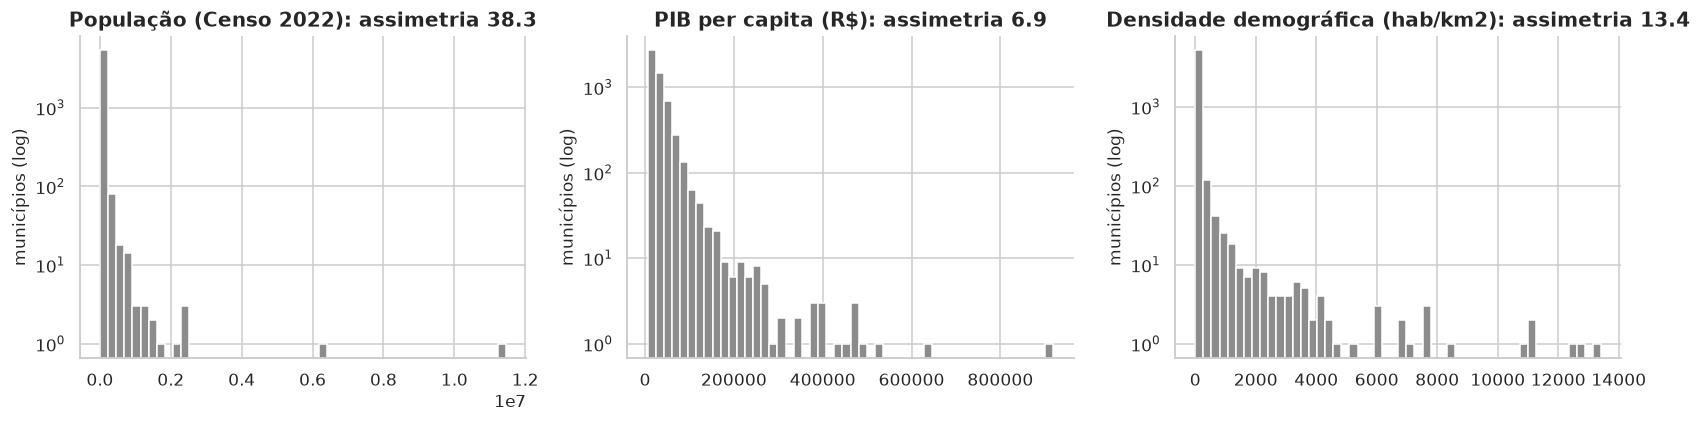

,assimetria
Densidade demográfica (hab/km2),13.36
PIB per capita (R$),6.91
"Taxa de abandono, anos iniciais (%)",4.77
Taxa de aprovação no 2o ano (%),-3.27
"Docentes com curso superior, anos iniciais (%)",-2.07
"Taxa de reprovação, anos iniciais (%)",1.66
"Distorção idade-série, anos iniciais (%)",1.50
Alunos em escolas rurais (%),1.47
"Docentes com formação adequada, anos iniciais (%)",-1.11
População (escala log),0.83


In [10]:
assimetria = d[numericas].skew().sort_values(key=abs, ascending=False)
assimetria.index = rotular(assimetria.index)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, v in zip(axes, ["populacao", "pib_per_capita", "densidade_hab_km2"]):
    ax.hist(d[v].dropna(), bins=50, color=CINZA)
    ax.set_title(f"{rotulo(v)}: assimetria {d[v].skew():.1f}")
    ax.set_yscale("log")
    ax.set_ylabel("municípios (log)")
salvar(fig, "02_assimetria")
plt.show()
assimetria.round(2).head(10).to_frame("assimetria")

In [11]:
nulos = mun[numericas + ["afd_ai_grupo5_pct", "ideb_anterior", "ideb_variacao"]].isna().mean().sort_values(ascending=False)
nulos = nulos[nulos > 0]
nulos.index = rotular(nulos.index)
(100 * nulos).round(1).to_frame("% de nulos (2024 e 2025)")

,% de nulos (2024 e 2025)
Variação do IDEB entre edições,9.8
IDEB anos iniciais (edição anterior),8.6
IDEB anos iniciais (última edição),2.4
Nota de português no Saeb 5o ano (última edição),2.3
Nível de alfabetização no ano anterior (0 a 5),2.1
Participação na prova no ano anterior (%),2.1
Salto necessário para a meta (p.p.),1.4
% alfabetizados no ano anterior,1.4
Tendência do IDEB (pontos por edição),1.2
Nível socioeconômico médio dos alunos (INSE),0.2


População, PIB per capita, densidade e área têm assimetria muito alta (caudas longas à direita), o que atrapalha modelos lineares e o escalonamento. Os nulos são poucos e concentrados no histórico (municípios sem resultado no ano anterior) e no IDEB (municípios sem edição anterior).

**Decisão:** transformação log1p para as variáveis de porte e renda, dentro do pipeline; imputação pela mediana para todas as numéricas, ajustada só no treino; e um indicador de ausência para o histórico (`indicador_t1` ausente é informativo: o município não teve resultado publicado).

## 8. O grão de aluno

O objetivo principal do desafio é prever se um aluno será alfabetizado. As variáveis disponíveis para um aluno são a rede, a UF, a escola (tamanho e presença na prova) e o contexto do município. Não há dado individual (sexo, idade, NSE do aluno) nos microdados. Isso limita o teto de qualquer modelo no grão de aluno, e a EDA aqui serve para dimensionar esse teto.

**H12.** A rede estadual tem proporção de alfabetizados diferente da municipal.
**H13.** Escolas com mais alunos avaliados têm proporção maior de alfabetizados.
**H14.** A maior parte da variação entre alunos está dentro da escola, não entre escolas ou municípios.

In [12]:
alunos = carregar_abt_aluno()
print(alunos.shape)
amostra = alunos.groupby(["ano", "alfabetizado"], group_keys=False).apply(lambda g: g.sample(frac=400_000 / len(alunos), random_state=SEED), include_groups=False)
amostra = alunos.loc[amostra.index]
print("amostra:", amostra.shape)

# H12: rede
tab = pd.crosstab(alunos["rede"], alunos["alfabetizado"])
chi2, p, _, _ = stats.chi2_contingency(tab)
taxa_rede = alunos.groupby(["ano", "rede"], observed=True)["alfabetizado"].agg(["mean", "size"])
taxa_rede["mean"] = (100 * taxa_rede["mean"]).round(1)
print(f"qui-quadrado rede x alfabetizado: {chi2:.0f} (p = {p:.1e})")
taxa_rede

(3817947, 63)


amostra: (399999, 63)


qui-quadrado rede x alfabetizado: 58 (p = 2.9e-13)


mean     size
ano  rede                    
2024 estadual   62.5   241074
     municipal  59.4  1610754
     privada    66.7       24
2025 estadual   64.7   243198
     municipal  66.5  1722897

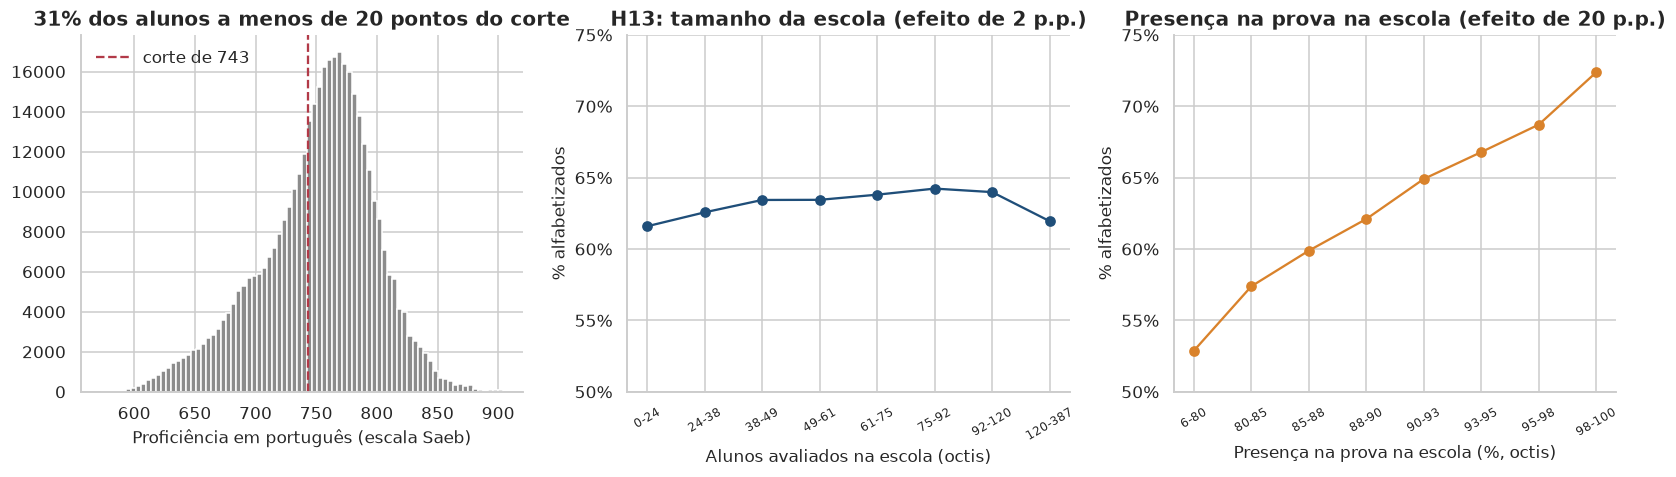

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# distribuicao da proficiencia com o corte de 743
axes[0].hist(amostra["proficiencia"], bins=80, color=CINZA)
axes[0].axvline(743, color=VERMELHO, ls="--", label="corte de 743")
faixa = amostra["proficiencia"].between(723, 763).mean()
axes[0].set_title(f"{100 * faixa:.0f}% dos alunos a menos de 20 pontos do corte")
axes[0].set_xlabel("Proficiência em português (escala Saeb)")
axes[0].legend()

# H13: tamanho da escola
dd = amostra.copy()
dd["faixa"] = pd.qcut(dd["escola_qtd_avaliados"], 8, duplicates="drop")
t = dd.groupby("faixa", observed=True)["alfabetizado"].mean()
axes[1].plot(range(len(t)), 100 * t.values, marker="o", color=AZUL)
axes[1].set_xticks(range(len(t)))
axes[1].set_xticklabels([f"{int(iv.left)}-{int(iv.right)}" for iv in t.index], rotation=30, fontsize=8)
axes[1].set_xlabel("Alunos avaliados na escola (octis)")
axes[1].set_ylabel("% alfabetizados")
axes[1].set_title("H13: tamanho da escola (efeito de 2 p.p.)")
axes[1].set_ylim(50, 75)
fmt_pct(axes[1], "y")

# presenca na escola
dd["faixa_p"] = pd.qcut(dd["escola_taxa_presenca"], 8, duplicates="drop")
t = dd.groupby("faixa_p", observed=True)["alfabetizado"].mean()
axes[2].plot(range(len(t)), 100 * t.values, marker="o", color=LARANJA)
axes[2].set_xticks(range(len(t)))
axes[2].set_xticklabels([f"{iv.left:.0f}-{iv.right:.0f}" for iv in t.index], rotation=30, fontsize=8)
axes[2].set_xlabel("Presença na prova na escola (%, octis)")
axes[2].set_ylabel("% alfabetizados")
axes[2].set_title("Presença na prova na escola (efeito de 20 p.p.)")
axes[2].set_ylim(50, 75)
fmt_pct(axes[2], "y")
salvar(fig, "02_grao_aluno")
plt.show()

In [14]:
# H14: decomposicao da variancia do alvo entre municipio, escola e aluno (2025)
a25 = alunos[alunos["ano"] == 2025]
total = a25["alfabetizado"].var()
media_mun = a25.groupby("id_municipio")["alfabetizado"].transform("mean")
media_esc = a25.groupby("id_escola")["alfabetizado"].transform("mean")
entre_mun = media_mun.var()
entre_esc_dentro_mun = (media_esc - media_mun).var()
dentro_esc = (a25["alfabetizado"] - media_esc).var()
decomp = pd.Series(
    {"entre municípios": entre_mun, "entre escolas do mesmo município": entre_esc_dentro_mun, "entre alunos da mesma escola": dentro_esc}
)
(100 * decomp / decomp.sum()).round(1).to_frame("% da variância do alvo (2025)")

,% da variância do alvo (2025)
entre municípios,8.3
entre escolas do mesmo município,7.1
entre alunos da mesma escola,84.6


H12 se confirma no teste (a diferença entre redes é significativa pelo tamanho da base), mas ela é pequena e muda de sinal entre os anos: em 2024 a rede estadual estava 3 pontos acima, em 2025 a municipal passou à frente. H13 se confirma só parcialmente: o tamanho da escola move a proporção de alfabetizados em cerca de 2 pontos, e as escolas muito grandes voltam a cair. O que pesa de verdade no nível da escola é a presença na prova: das escolas com presença abaixo de 80% para as com presença quase total, a proporção de alfabetizados sobe de 52% para 72%. Ausência não é aleatória; escolas onde muitos alunos faltam à prova também alfabetizam menos.

H14 é o achado que dimensiona o problema: cerca de 85% da variação do alvo está **entre alunos da mesma escola**, e o modelo não tem nenhuma variável nesse nível. Municípios e escolas, somados, respondem por 15%. O teto do modelo de aluno é explicar essa fatia. Junte-se a isso a concentração de alunos perto do corte de 743 (uma diferença de poucos pontos muda a classe) e fica claro que um AUC muito alto seria suspeito, não desejável. O ganho útil do modelo de aluno está em ordenar bem o risco entre escolas e municípios, não em acertar o aluno individual.

**Decisão:** o modelo de aluno usa rede, UF, tamanho e presença da escola e o contexto municipal; os pesos amostrais entram na avaliação; a métrica principal é o AUC-ROC (independe do limiar) com recall da classe "não alfabetizado" como métrica de política; e o teto de variância explicável fica documentado como limitação.

## 9. Da EDA para a modelagem

| Achado | Hipótese | Decisão de modelagem |
|---|---|---|
| UF explica um terço da variação; região explica quase nada | H1 | UF como categórica (one-hot); região fora; validação com grupos de município |
| Porte e ruralidade pesam mais que INSE e PIB per capita, que têm correlação fraca | H2, H3, H4 | entram como numéricas; log nas variáveis de porte e renda; expectativa de peso baixo no SHAP |
| Abandono, reprovação e distorção idade-série são os contextos mais fortes; formação docente e alunos por turma têm sinal claro e efeito pequeno | H5, H6, H7, H8 | relações não lineares: árvores e boosting além da logística |
| Resultado anterior e IDEB são os preditores mais fortes | H9, H10 | histórico entra; ablação obrigatória (com e sem histórico) |
| Chance de atingir a meta cai com o salto necessário; 2025 deslocado para cima; regressão à média em 2024 | H11 | `salto_necessario` como variável; teste temporal 2024 → 2025; saída em probabilidade |
| Pares colineares conhecidos | bloco 6 | L2 na logística; `nivel_t1` e `meta_t` fora; SHAP lido por pares |
| Assimetria alta e nulos concentrados no histórico | bloco 7 | log1p no pipeline; mediana no treino; indicador de ausência do histórico |
| 85% da variância do aluno está dentro da escola; muitos alunos perto do corte | H12, H13, H14 | métricas com peso amostral; AUC como principal; teto documentado |

O próximo notebook constrói o pipeline do modelo de aluno seguindo exatamente estas decisões.